In [13]:
from owlready2 import get_ontology

onto = get_ontology("data/family.owl").load()

with onto:
    class oldPerson(onto.Person):
        pass

for person in onto.Person.instances():
    if person.age and person.age > 60:
        person.is_a.append(oldPerson)
        print(f"{person.name} is classified as oldPerson (age: {person.age})")

print(f"Total oldPersons inferred: {len(list(oldPerson.instances()))}")

Peter is classified as oldPerson (age: 70)
Marie is classified as oldPerson (age: 69)
Total oldPersons inferred: 2


In [14]:
import rdflib
import pandas as pd
from pykeen.triples import TriplesFactory
import numpy as np

g = rdflib.Graph()
g.parse("data/KB_construction/expanded_graph.ttl", format="turtle")

triples = [[str(s), str(p), str(o)] for s, p, o in g]
df = pd.DataFrame(triples, columns=["head", "relation", "tail"]).drop_duplicates()

entity_counts = pd.concat([df["head"], df["tail"]]).value_counts()
valid_entities = set(entity_counts[entity_counts >= 2].index)

df = df[df["head"].isin(valid_entities) & df["tail"].isin(valid_entities)]

rdf_type = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"
owl_same_as = "http://www.w3.org/2002/07/owl#sameAs"
person_class = "http://myproject.org/ontology/PERSON"
key_actor_class = "http://myproject.org/ontology/KeyFinancialActor"

rule_text = "PERSON(?p) ^ owl:sameAs(?p, ?e) -> KeyFinancialActor(?p)"
person_entities = set(df[(df["relation"] == rdf_type) & (df["tail"] == person_class)]["head"])

candidate_entities = df[(df["relation"] == owl_same_as) & (df["head"].isin(person_entities))][["head"]].drop_duplicates()
inferred_types = candidate_entities.assign(relation=rdf_type, tail=key_actor_class)[["head", "relation", "tail"]]

before_size = len(df)
df = pd.concat([df, inferred_types], ignore_index=True).drop_duplicates()
after_size = len(df)
added = after_size - before_size

print(f"Applied rule: {rule_text}")
print(f"Inferred KeyFinancialActor triples added: {added}")

if added > 0:
    inferred_people = sorted(inferred_types["head"].unique())
    print(f"Number of inferred KeyFinancialActor persons: {len(inferred_people)}")
    for uri in inferred_people[:20]:
        print(f"Inferred Actor: {uri.rsplit('/', 1)[-1]}")

tf = TriplesFactory.from_labeled_triples(df.values)
training, testing, validation = tf.split([0.8, 0.1, 0.1], random_state=42)

def save_triples(dataset, filename):
    df_out = pd.DataFrame(dataset.label_triples(dataset.mapped_triples))
    df_out.to_csv(filename, sep="\t", index=False, header=False)

save_triples(training, "data/embedding/train.txt")
save_triples(validation, "data/embedding/valid.txt")
save_triples(testing, "data/embedding/test.txt")

print(f"Total triples: {len(df)}")
print(f"Total entities: {len(tf.entity_id_to_label)}")
print(f"Total relations: {len(tf.relation_id_to_label)}")
print(f"Training size: {training.num_triples}")
print(f"Validation size: {validation.num_triples}")
print(f"Test size: {testing.num_triples}")

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [1900, 534, 534]


Applied rule: PERSON(?p) ^ owl:sameAs(?p, ?e) -> KeyFinancialActor(?p)
Inferred KeyFinancialActor triples added: 22
Number of inferred KeyFinancialActor persons: 22
Inferred Actor: Andrew_Ross_Sorkin
Inferred Actor: Baiju_Bhatt
Inferred Actor: Bhatt
Inferred Actor: Caroline
Inferred Actor: Elon_Musk
Inferred Actor: Gill
Inferred Actor: Jaime_Rogozinski
Inferred Actor: Keith_Gill
Inferred Actor: Keith_Patrick_Gill
Inferred Actor: Keith_Patrick_Gill%5B1
Inferred Actor: Ken_Griffin%27s
Inferred Actor: Martin_Shkreli
Inferred Actor: Melvin
Inferred Actor: Michael_Steinberg
Inferred Actor: Plotkin
Inferred Actor: Robin_Hood
Inferred Actor: Rogozinski
Inferred Actor: Ryan_Cohen
Inferred Actor: Steve_Cohen%27s
Inferred Actor: Steven
Total triples: 5337
Total entities: 2384
Total relations: 317
Training size: 4269
Validation size: 534
Test size: 534


In [15]:
from pykeen.pipeline import pipeline

results_transe = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model="TransE",
    model_kwargs=dict(embedding_dim=100),
    training_kwargs=dict(num_epochs=50, batch_size=256),
    evaluator="RankBasedEvaluator",
    random_seed=42
)

results_complex = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model="ComplEx",
    model_kwargs=dict(embedding_dim=100),
    training_kwargs=dict(num_epochs=50, batch_size=256),
    evaluator="RankBasedEvaluator",
    random_seed=42
)

print("TransE Results:")
print(results_transe.metric_results.to_df())
print("\nComplEx Results:")
print(results_complex.metric_results.to_df())

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
c:\Users\maxim\Desktop\Projets\WebDatamining\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 50/50 [00:13<00:00,  3.60epoch/s, loss=0.0168, prev_loss=0.0161]
Evaluating on cpu:   0%|          | 0.00/534 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 534/534 [00:00<00:00, 1.99ktriple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 0.28s seconds
INFO:pykeen.pipeline.api:Using device: Non

TransE Results:
     Side    Rank_type                               Metric     Value
0    head   optimistic  adjusted_inverse_harmonic_mean_rank  0.050092
1    tail   optimistic  adjusted_inverse_harmonic_mean_rank  0.022628
2    both   optimistic  adjusted_inverse_harmonic_mean_rank  0.036360
3    head    realistic  adjusted_inverse_harmonic_mean_rank  0.050092
4    tail    realistic  adjusted_inverse_harmonic_mean_rank  0.022628
..    ...          ...                                  ...       ...
220  tail    realistic                   adjusted_hits_at_k  0.055951
221  both    realistic                   adjusted_hits_at_k  0.102969
222  head  pessimistic                   adjusted_hits_at_k  0.149987
223  tail  pessimistic                   adjusted_hits_at_k  0.055951
224  both  pessimistic                   adjusted_hits_at_k  0.102969

[225 rows x 4 columns]

ComplEx Results:
     Side    Rank_type                               Metric     Value
0    head   optimistic  adjusted

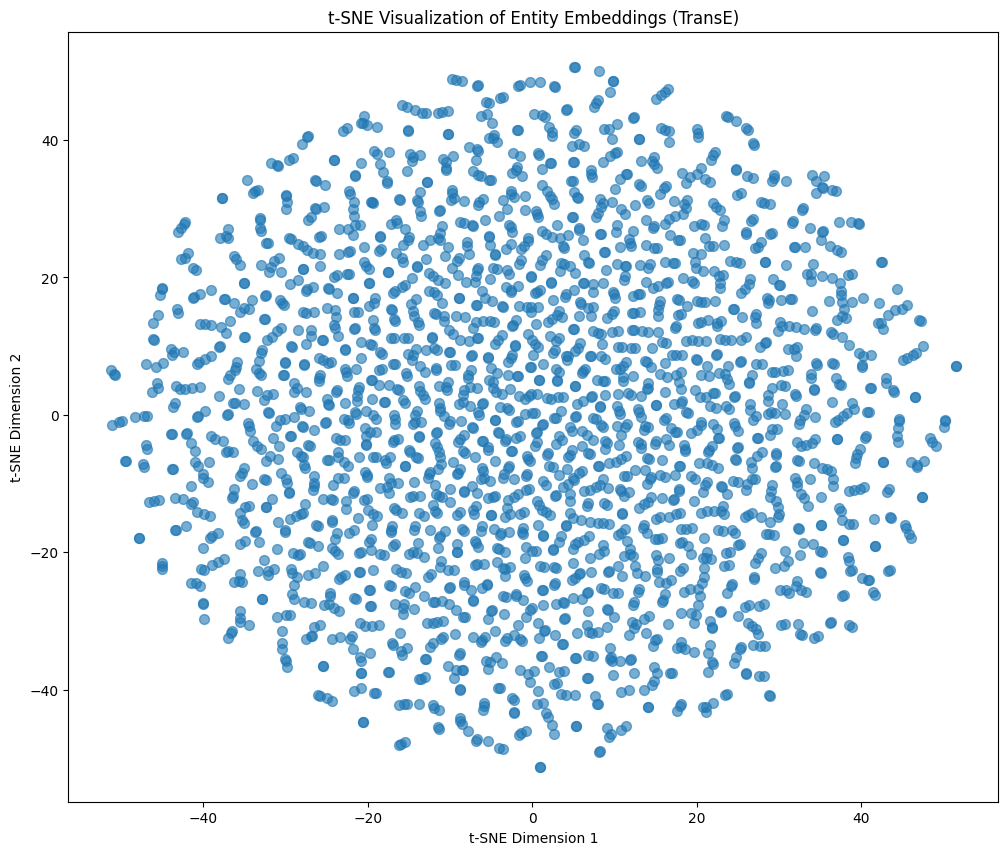

Entity: http://commons.wikimedia.org/wiki/Special:FilePath/2013-01%20happy-new-year%20003%20net.jpg
Nearest neighbors:
1. http://www.wikidata.org/entity/Q69306319 (distance: 1.1308)
2. http://www.wikidata.org/entity/Q136776637 (distance: 1.1579)
3. http://www.wikidata.org/entity/Q1998 (distance: 1.1684)
4. http://www.wikidata.org/entity/statement/Q30-9F1527A3-13F3-4342-8E62-09FF8E5F71BF (distance: 1.1740)
5. http://www.wikidata.org/entity/Q69305932 (distance: 1.1757)


In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

model = results_transe.model
entity_embeddings = model.entity_representations[0](indices=None).detach().cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(entity_embeddings)

plt.figure(figsize=(12, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, s=50)
plt.title("t-SNE Visualization of Entity Embeddings (TransE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.savefig("data/embedding/tsne_plot.png", dpi=100, bbox_inches='tight')
plt.show()

target_idx = 0
distances = pairwise_distances(entity_embeddings[target_idx].reshape(1, -1), entity_embeddings)
nearest_indices = distances.argsort()[0][1:6]

target_entity = list(tf.entity_to_id.keys())[list(tf.entity_to_id.values()).index(target_idx)]
print(f"Entity: {target_entity}")
print("Nearest neighbors:")
for i, idx in enumerate(nearest_indices, 1):
    neighbor = list(tf.entity_to_id.keys())[list(tf.entity_to_id.values()).index(idx)]
    dist = distances[0][idx]
    print(f"{i}. {neighbor} (distance: {dist:.4f})")

In [17]:
import torch

print("=== SWRL vs Embedding Comparison ===")

rdf_type = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"
key_actor_type = "http://myproject.org/ontology/KeyFinancialActor"

swrl_inferred = df[(df["relation"] == rdf_type) & (df["tail"] == key_actor_type)]["head"].drop_duplicates().tolist()
print(f"1. SWRL inferred KeyFinancialActor count: {len(swrl_inferred)}")
if swrl_inferred:
    preview = [uri.rsplit("/", 1)[-1] for uri in swrl_inferred[:5]]
    print(f"   Examples: {preview}")
else:
    print("   No inferred KeyFinancialActor triples found in current dataframe.")

if swrl_inferred and rdf_type in tf.relation_to_id and key_actor_type in tf.entity_to_id:
    actor_uri = next((u for u in swrl_inferred if u in tf.entity_to_id), None)

    if actor_uri is not None:
        actor_id = tf.entity_to_id[actor_uri]
        rel_id = tf.relation_to_id[rdf_type]
        tail_id = tf.entity_to_id[key_actor_type]

        ent = model.entity_representations[0](indices=None).detach()
        rel = model.relation_representations[0](indices=None).detach()

        pred = ent[actor_id] + rel[rel_id]
        true_dist = torch.norm(pred - ent[tail_id], p=2).item()

        all_distances = torch.norm(pred.unsqueeze(0) - ent, dim=1, p=2)
        rank = int((all_distances < all_distances[tail_id]).sum().item() + 1)

        neg_tail_id = (tail_id + 1) % tf.num_entities
        neg_dist = torch.norm(pred - ent[neg_tail_id], p=2).item()

        print("\n2. Embedding check (TransE):")
        print(f"   Tested inferred fact: ({actor_uri.rsplit('/', 1)[-1]}, rdf:type, KeyFinancialActor)")
        print(f"   True tail distance: {true_dist:.4f}")
        print(f"   Random negative distance: {neg_dist:.4f}")
        print(f"   Tail rank among all entities (lower is better): {rank}/{tf.num_entities}")
    else:
        print("\n2. Embedding check (TransE):")
        print("   No SWRL-inferred actor is present in tf.entity_to_id.")
else:
    print("\n2. Embedding check (TransE):")
    print("   Missing one of required mappings: rdf:type relation or KeyFinancialActor entity.")

print("\n3. Interpretation:")
print("   - SWRL gives explicit symbolic inferences (discrete facts).")
print("   - Embeddings score plausibility of those facts in latent space.")
print("   - If true-tail distance is lower and rank is good, embedding is consistent with SWRL inference.")

=== SWRL vs Embedding Comparison ===
1. SWRL inferred KeyFinancialActor count: 22
   Examples: ['Ryan_Cohen', 'Elon_Musk', 'Bhatt', 'Keith_Patrick_Gill%5B1', 'Robin_Hood']

2. Embedding check (TransE):
   Tested inferred fact: (Ryan_Cohen, rdf:type, KeyFinancialActor)
   True tail distance: 1.4970
   Random negative distance: 1.8609
   Tail rank among all entities (lower is better): 10/2384

3. Interpretation:
   - SWRL gives explicit symbolic inferences (discrete facts).
   - Embeddings score plausibility of those facts in latent space.
   - If true-tail distance is lower and rank is good, embedding is consistent with SWRL inference.
